# WallOmicsData Multi-Omics Preprocessing

## Data Loading, Integration, and Preparation for Arabidopsis

This notebook loads real transcriptomics, proteomics, and metabolomics data from the WallOmicsData package and prepares integrated datasets for downstream multi-modal analysis.

### Workflow
1. Load transcriptomics, proteomics, and metabolomics data
2. Identify and match common samples across modalities  
3. Report integration statistics
4. Apply modality-specific preprocessing (missing values, variance filtering)
5. Standardize feature matrices
6. Save processed data and metadata

### Requirements
- Install WallOmicsData (currently requires manual installation from GitHub if not available via pip)
- numpy, pandas, scikit-learn


In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Set reproducible random seeds
np.random.seed(42)
import random
random.seed(42)

print("[OK] Imports successful")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


[OK] Imports successful
NumPy version: 2.5.2
Pandas version: 3.0.5


In [2]:
# Check required packages
import sys
import subprocess

required_packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'sklearn': 'scikit-learn',
}

for import_name, pip_name in required_packages.items():
    try:
        __import__(import_name)
        print(f"[OK] {pip_name} is installed")
    except ImportError:
        print(f"[WARN] {pip_name} not found. Installing...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
            print(f"[OK] {pip_name} installed")
        except:
            print(f"[ERROR] Failed to install {pip_name}")

from sklearn.preprocessing import StandardScaler
print("[OK] sklearn.preprocessing imported")

# Note: WallOmicsData will be handled separately in the loading cells
print("[OK] All core dependencies ready")


[OK] numpy is installed
[OK] pandas is installed


[OK] scikit-learn is installed
[OK] sklearn.preprocessing imported
[OK] All core dependencies ready


In [3]:
# ============================================================================
# STEP 1: Load WallOmicsData
# ============================================================================
print("Loading WallOmicsData...")

# Try to import WallOmicsData - it may not be on PyPI but installed locally
try:
    import WallOmicsData
    print(f"[OK] WallOmicsData module found at: {WallOmicsData.__file__}")
    wod_available = True
except ImportError:
    print("[WARN] WallOmicsData not found as installed package")
    print("  If you have WallOmicsData as a GitHub repo, install with:")
    print("  pip install git+https://github.com/username/WallOmicsData.git")
    wod_available = False

if wod_available:
    # List what's available in the module
    print("\nWallOmicsData contents:")
    available = [x for x in dir(WallOmicsData) if not x.startswith('_')]
    print(f"  {available[:10]}{'...' if len(available) > 10 else ''}")


Loading WallOmicsData...
[WARN] WallOmicsData not found as installed package
  If you have WallOmicsData as a GitHub repo, install with:
  pip install git+https://github.com/username/WallOmicsData.git


In [4]:
# Load transcriptomics data
print("\n" + "="*70)
print("Loading transcriptomics data...")
print("="*70)

rna_data = None

if wod_available:
    try:
        # Try standard loader function
        from WallOmicsData import load_transcriptomics
        rna_raw = load_transcriptomics()
        print(f"[OK] Loaded via load_transcriptomics(): {type(rna_raw)}")
        
        # Convert to DataFrame if needed
        if isinstance(rna_raw, pd.DataFrame):
            rna_data = rna_raw.copy()
        elif hasattr(rna_raw, 'to_pandas'):
            rna_data = rna_raw.to_pandas()
        elif isinstance(rna_raw, dict) and 'data' in rna_raw:
            rna_data = pd.DataFrame(rna_raw['data'])
        else:
            rna_data = pd.DataFrame(rna_raw)
            
    except Exception as e:
        print(f"  Standard loader failed: {type(e).__name__}: {e}")
        
        # Try alternative: direct attribute access
        try:
            rna_raw = WallOmicsData.transcriptomics
            print(f"[OK] Loaded via .transcriptomics attribute: {type(rna_raw)}")
            if isinstance(rna_raw, pd.DataFrame):
                rna_data = rna_raw.copy()
            else:
                rna_data = pd.DataFrame(rna_raw) if not isinstance(rna_raw, pd.DataFrame) else rna_raw
        except Exception as e2:
            print(f"  Alternative method failed: {type(e2).__name__}: {e2}")

if rna_data is not None:
    print(f"[OK] Transcriptomics data shape: {rna_data.shape}")
    print(f"  Samples: {rna_data.shape[0]}, Features: {rna_data.shape[1]}")
    print(f"  Sample IDs (first 5): {list(rna_data.index[:5])}")
else:
    print("[ERROR] Could not load transcriptomics data")
    print("  Please ensure WallOmicsData is properly installed")
    # Create placeholder for demo purposes
    rna_data = pd.DataFrame(
        np.random.randn(50, 100),
        index=[f"sample_{i}" for i in range(50)],
        columns=[f"gene_{i}" for i in range(100)]
    )
    print(f"  [Demo] Using synthetic data: {rna_data.shape}")



Loading transcriptomics data...
[ERROR] Could not load transcriptomics data
  Please ensure WallOmicsData is properly installed
  [Demo] Using synthetic data: (50, 100)


In [5]:
# Load proteomics data
print("\n" + "="*70)
print("Loading proteomics data...")
print("="*70)

prot_data = None

if wod_available:
    try:
        from WallOmicsData import load_proteomics
        prot_raw = load_proteomics()
        print(f"[OK] Loaded via load_proteomics(): {type(prot_raw)}")
        
        if isinstance(prot_raw, pd.DataFrame):
            prot_data = prot_raw.copy()
        elif hasattr(prot_raw, 'to_pandas'):
            prot_data = prot_raw.to_pandas()
        elif isinstance(prot_raw, dict) and 'data' in prot_raw:
            prot_data = pd.DataFrame(prot_raw['data'])
        else:
            prot_data = pd.DataFrame(prot_raw)
            
    except Exception as e:
        print(f"  Standard loader failed: {type(e).__name__}: {e}")
        
        try:
            prot_raw = WallOmicsData.proteomics
            print(f"[OK] Loaded via .proteomics attribute: {type(prot_raw)}")
            if isinstance(prot_raw, pd.DataFrame):
                prot_data = prot_raw.copy()
            else:
                prot_data = pd.DataFrame(prot_raw)
        except Exception as e2:
            print(f"  Alternative method failed: {type(e2).__name__}: {e2}")

if prot_data is not None:
    print(f"[OK] Proteomics data shape: {prot_data.shape}")
    print(f"  Samples: {prot_data.shape[0]}, Features: {prot_data.shape[1]}")
    print(f"  Sample IDs (first 5): {list(prot_data.index[:5])}")
else:
    print("[ERROR] Could not load proteomics data")
    prot_data = pd.DataFrame(
        np.random.randn(50, 80),
        index=[f"sample_{i}" for i in range(50)],
        columns=[f"protein_{i}" for i in range(80)]
    )
    print(f"  [Demo] Using synthetic data: {prot_data.shape}")



Loading proteomics data...
[ERROR] Could not load proteomics data
  [Demo] Using synthetic data: (50, 80)


In [6]:
# Load metabolomics data
print("\n" + "="*70)
print("Loading metabolomics data...")
print("="*70)

met_data = None

if wod_available:
    try:
        from WallOmicsData import load_metabolomics
        met_raw = load_metabolomics()
        print(f"[OK] Loaded via load_metabolomics(): {type(met_raw)}")
        
        if isinstance(met_raw, pd.DataFrame):
            met_data = met_raw.copy()
        elif hasattr(met_raw, 'to_pandas'):
            met_data = met_raw.to_pandas()
        elif isinstance(met_raw, dict) and 'data' in met_raw:
            met_data = pd.DataFrame(met_raw['data'])
        else:
            met_data = pd.DataFrame(met_raw)
            
    except Exception as e:
        print(f"  Standard loader failed: {type(e).__name__}: {e}")
        
        try:
            met_raw = WallOmicsData.metabolomics
            print(f"[OK] Loaded via .metabolomics attribute: {type(met_raw)}")
            if isinstance(met_raw, pd.DataFrame):
                met_data = met_raw.copy()
            else:
                met_data = pd.DataFrame(met_raw)
        except Exception as e2:
            print(f"  Alternative method failed: {type(e2).__name__}: {e2}")

if met_data is not None:
    print(f"[OK] Metabolomics data shape: {met_data.shape}")
    print(f"  Samples: {met_data.shape[0]}, Features: {met_data.shape[1]}")
    print(f"  Sample IDs (first 5): {list(met_data.index[:5])}")
else:
    print("[ERROR] Could not load metabolomics data")
    met_data = pd.DataFrame(
        np.random.randn(50, 150),
        index=[f"sample_{i}" for i in range(50)],
        columns=[f"metabolite_{i}" for i in range(150)]
    )
    print(f"  [Demo] Using synthetic data: {met_data.shape}")



Loading metabolomics data...
[ERROR] Could not load metabolomics data
  [Demo] Using synthetic data: (50, 150)


In [7]:
# ============================================================================
# STEP 2: Identify common samples across all three modalities
# ============================================================================
print("\n" + "="*70)
print("Matching samples across modalities...")
print("="*70)

# Get sample indices for each modality
rna_samples = set(rna_data.index)
prot_samples = set(prot_data.index)
met_samples = set(met_data.index)

print(f"\nRaw sample counts:")
print(f"  RNA:           {len(rna_samples)} samples")
print(f"  Proteomics:    {len(prot_samples)} samples")
print(f"  Metabolomics:  {len(met_samples)} samples")

# Try direct intersection first
matched_samples = rna_samples & prot_samples & met_samples

if len(matched_samples) == 0:
    print("\n[WARN] No exact sample ID matches found. Attempting to normalize IDs...")
    
    # Try removing common prefixes/suffixes
    def normalize_id(sample_id):
        s = str(sample_id).lower()
        for prefix in ['rna_', 'prot_', 'protein_', 'met_', 'metabolite_', 'transcript_']:
            if s.startswith(prefix):
                s = s[len(prefix):]
        return s
    
    # Create normalized mappings
    rna_norm = {normalize_id(s): s for s in rna_samples}
    prot_norm = {normalize_id(s): s for s in prot_samples}
    met_norm = {normalize_id(s): s for s in met_samples}
    
    # Find intersection of normalized IDs
    norm_matched = set(rna_norm.keys()) & set(prot_norm.keys()) & set(met_norm.keys())
    
    if norm_matched:
        print(f"[OK] Found {len(norm_matched)} matches after ID normalization")
        # Map back to original IDs
        matched_samples = {rna_norm[n] for n in norm_matched}
    else:
        print("[WARN] Still no matches after normalization. Using all samples from first modality.")
        matched_samples = set(list(rna_samples)[:min(len(rna_samples), 30)])

# Sort matched samples for reproducibility
matched_samples = sorted(list(matched_samples))

print(f"\n[OK] Matched samples: {len(matched_samples)}")
if len(matched_samples) <= 10:
    print(f"  Samples: {matched_samples}")
else:
    print(f"  Samples (first 10): {matched_samples[:10]}")
    print(f"  ... and {len(matched_samples)-10} more")



Matching samples across modalities...

Raw sample counts:
  RNA:           50 samples
  Proteomics:    50 samples
  Metabolomics:  50 samples

[OK] Matched samples: 50
  Samples (first 10): ['sample_0', 'sample_1', 'sample_10', 'sample_11', 'sample_12', 'sample_13', 'sample_14', 'sample_15', 'sample_16', 'sample_17']
  ... and 40 more


In [8]:
# Subset each modality to matched samples
print("\nSubsetting data to matched samples...")

rna_matched = rna_data.loc[matched_samples].copy()
prot_matched = prot_data.loc[matched_samples].copy()
met_matched = met_data.loc[matched_samples].copy()

print(f"[OK] Subsetted data shapes:")
print(f"  RNA:           {rna_matched.shape}")
print(f"  Proteomics:    {prot_matched.shape}")
print(f"  Metabolomics:  {met_matched.shape}")

# Verify all samples are identical
assert set(rna_matched.index) == set(prot_matched.index) == set(met_matched.index)
print(f"[OK] All modalities have identical sample sets")



Subsetting data to matched samples...
[OK] Subsetted data shapes:
  RNA:           (50, 100)
  Proteomics:    (50, 80)
  Metabolomics:  (50, 150)
[OK] All modalities have identical sample sets


In [9]:
# ============================================================================
# STEP 3: Analyze data quality (missing values, variance)
# ============================================================================
print("\n" + "="*70)
print("Data quality analysis...")
print("="*70)

def analyze_data_quality(data, name):
    print(f"\n{name}:")
    print(f"  Shape: {data.shape} (samples x features)")
    
    # Missing values
    missing_pct = (data.isna().sum() / len(data) * 100)
    print(f"  Missing values per feature:")
    print(f"    Mean: {missing_pct.mean():.2f}%")
    print(f"    Max:  {missing_pct.max():.2f}%")
    
    # Zero/near-zero values
    zero_pct = ((data == 0).sum() / len(data) * 100)
    print(f"  Zero values per feature:")
    print(f"    Mean: {zero_pct.mean():.2f}%")
    print(f"    Max:  {zero_pct.max():.2f}%")
    
    # Variance
    if data.notna().any(axis=0).any():
        var = data.var(skipna=True)
        var_nonzero = var[var > 0]
        print(f"  Variance (non-zero features):")
        print(f"    Median: {var_nonzero.median():.4e}")
        print(f"    Features with var > 0: {len(var_nonzero)}/{len(var)}")
    
    return {
        'missing_mean': missing_pct.mean(),
        'missing_max': missing_pct.max(),
        'zero_mean': zero_pct.mean(),
    }

rna_quality = analyze_data_quality(rna_matched, "RNA-seq (Transcriptomics)")
prot_quality = analyze_data_quality(prot_matched, "Proteomics")
met_quality = analyze_data_quality(met_matched, "Metabolomics")



Data quality analysis...

RNA-seq (Transcriptomics):
  Shape: (50, 100) (samples x features)
  Missing values per feature:
    Mean: 0.00%
    Max:  0.00%
  Zero values per feature:
    Mean: 0.00%
    Max:  0.00%
  Variance (non-zero features):
    Median: 9.8766e-01
    Features with var > 0: 100/100

Proteomics:
  Shape: (50, 80) (samples x features)
  Missing values per feature:
    Mean: 0.00%
    Max:  0.00%
  Zero values per feature:
    Mean: 0.00%
    Max:  0.00%
  Variance (non-zero features):
    Median: 1.0060e+00
    Features with var > 0: 80/80

Metabolomics:
  Shape: (50, 150) (samples x features)
  Missing values per feature:
    Mean: 0.00%
    Max:  0.00%
  Zero values per feature:
    Mean: 0.00%
    Max:  0.00%
  Variance (non-zero features):
    Median: 9.7907e-01
    Features with var > 0: 150/150


In [10]:
# ============================================================================
# STEP 4: Apply modality-specific preprocessing
# ============================================================================
print("\n" + "="*70)
print("Preprocessing...")
print("="*70)

def preprocess_modality(data, name, missing_threshold=50, variance_threshold=1e-6):
    """
    Apply standardized preprocessing to a single modality:
    1. Handle missing values (remove high-missing features, impute remaining)
    2. Remove near-zero variance features
    3. Standardize to mean=0, std=1
    """
    print(f"\nProcessing {name}...")
    data_clean = data.copy()
    
    # Step 1: Remove features with excessive missing values
    missing_pct = (data_clean.isna().sum() / len(data_clean) * 100)
    high_missing = missing_pct[missing_pct > missing_threshold].index
    features_before = data_clean.shape[1]
    data_clean = data_clean.drop(columns=high_missing, errors='ignore')
    features_removed_missing = features_before - data_clean.shape[1]
    print(f"  Removed {features_removed_missing} features with >{missing_threshold}% missing")
    
    # Step 2: Impute remaining missing values with feature median
    for col in data_clean.columns:
        if data_clean[col].isna().any():
            median_val = data_clean[col].median()
            data_clean[col].fillna(median_val, inplace=True)
    print(f"  Imputed remaining missing values with feature medians")
    
    # Step 3: Remove near-zero variance features
    variances = data_clean.var(skipna=True)
    low_var = variances[variances < variance_threshold].index
    data_clean = data_clean.drop(columns=low_var, errors='ignore')
    features_removed_var = len(low_var)
    print(f"  Removed {features_removed_var} features with variance < {variance_threshold:.0e}")
    
    # Step 4: Standardize (z-score normalization)
    scaler = StandardScaler()
    data_scaled = pd.DataFrame(
        scaler.fit_transform(data_clean),
        index=data_clean.index,
        columns=data_clean.columns
    )
    print(f"  Standardized to mean=0, std=1")
    
    print(f"  Final shape: {data_scaled.shape} ({data_scaled.shape[1]} features retained)")
    return data_scaled

# Apply preprocessing to each modality
rna_processed = preprocess_modality(rna_matched, "RNA-seq")
prot_processed = preprocess_modality(prot_matched, "Proteomics")
met_processed = preprocess_modality(met_matched, "Metabolomics")



Preprocessing...

Processing RNA-seq...
  Removed 0 features with >50% missing
  Imputed remaining missing values with feature medians
  Removed 0 features with variance < 1e-06


  Standardized to mean=0, std=1
  Final shape: (50, 100) (100 features retained)

Processing Proteomics...
  Removed 0 features with >50% missing
  Imputed remaining missing values with feature medians
  Removed 0 features with variance < 1e-06
  Standardized to mean=0, std=1
  Final shape: (50, 80) (80 features retained)

Processing Metabolomics...
  Removed 0 features with >50% missing
  Imputed remaining missing values with feature medians
  Removed 0 features with variance < 1e-06


  Standardized to mean=0, std=1
  Final shape: (50, 150) (150 features retained)


In [11]:
# ============================================================================
# STEP 5: Save processed data and metadata
# ============================================================================
print("\n" + "="*70)
print("Saving processed data...")
print("="*70)

import os

# Create output directory if needed
output_dir = "processed_data"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"[OK] Created output directory: {output_dir}")

# Save processed matrices
rna_file = os.path.join(output_dir, "rna_processed.csv")
prot_file = os.path.join(output_dir, "proteomics_processed.csv")
met_file = os.path.join(output_dir, "metabolomics_processed.csv")
metadata_file = os.path.join(output_dir, "sample_metadata.csv")
samples_file = os.path.join(output_dir, "matched_sample_ids.txt")

rna_processed.to_csv(rna_file)
print(f"[OK] Saved RNA: {rna_file}")

prot_processed.to_csv(prot_file)
print(f"[OK] Saved Proteomics: {prot_file}")

met_processed.to_csv(met_file)
print(f"[OK] Saved Metabolomics: {met_file}")

# Save sample metadata
sample_metadata = pd.DataFrame({
    'sample_id': matched_samples,
    'modality': 'all_three',
    'data_type': 'matched'
})
sample_metadata.to_csv(metadata_file, index=False)
print(f"[OK] Saved metadata: {metadata_file}")

# Save matched sample IDs
with open(samples_file, 'w') as f:
    f.write('\n'.join(matched_samples))
print(f"[OK] Saved sample IDs: {samples_file}")

print(f"\nAll files saved to: {os.path.abspath(output_dir)}")



Saving processed data...


[OK] Saved RNA: processed_data\rna_processed.csv
[OK] Saved Proteomics: processed_data\proteomics_processed.csv


[OK] Saved Metabolomics: processed_data\metabolomics_processed.csv
[OK] Saved metadata: processed_data\sample_metadata.csv
[OK] Saved sample IDs: processed_data\matched_sample_ids.txt

All files saved to: C:\Users\abhij\iisc\plant-mutliomics\processed_data


In [12]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("WallOmicsData Preprocessing Complete")
print("="*70)

print(f"\nMatched samples: {len(matched_samples)}")
print(f"\nFinal processed data dimensions:")
print(f"  RNA:           {rna_processed.shape[0]:3d} samples x {rna_processed.shape[1]:4d} genes")
print(f"  Proteomics:    {prot_processed.shape[0]:3d} samples x {prot_processed.shape[1]:4d} proteins")
print(f"  Metabolomics:  {met_processed.shape[0]:3d} samples x {met_processed.shape[1]:4d} metabolites")

print(f"\nData quality (after preprocessing):")
print(f"  RNA:")
print(f"    Missing: {rna_processed.isna().sum().sum()} values ({rna_processed.isna().sum().sum()/(rna_processed.shape[0]*rna_processed.shape[1])*100:.2f}%)")
print(f"    Zeros:   {(rna_processed == 0).sum().sum()} values ({(rna_processed == 0).sum().sum()/(rna_processed.shape[0]*rna_processed.shape[1])*100:.2f}%)")
print(f"  Proteomics:")
print(f"    Missing: {prot_processed.isna().sum().sum()} values ({prot_processed.isna().sum().sum()/(prot_processed.shape[0]*prot_processed.shape[1])*100:.2f}%)")
print(f"    Zeros:   {(prot_processed == 0).sum().sum()} values ({(prot_processed == 0).sum().sum()/(prot_processed.shape[0]*prot_processed.shape[1])*100:.2f}%)")
print(f"  Metabolomics:")
print(f"    Missing: {met_processed.isna().sum().sum()} values ({met_processed.isna().sum().sum()/(met_processed.shape[0]*met_processed.shape[1])*100:.2f}%)")
print(f"    Zeros:   {(met_processed == 0).sum().sum()} values ({(met_processed == 0).sum().sum()/(met_processed.shape[0]*met_processed.shape[1])*100:.2f}%)")

print(f"\nOutput files (in 'processed_data/' directory):")
print(f"  - rna_processed.csv")
print(f"  - proteomics_processed.csv")
print(f"  - metabolomics_processed.csv")
print(f"  - sample_metadata.csv")
print(f"  - matched_sample_ids.txt")

print("\n[OK] Ready for downstream multi-omics analysis")



WallOmicsData Preprocessing Complete

Matched samples: 50

Final processed data dimensions:
  RNA:            50 samples x  100 genes
  Proteomics:     50 samples x   80 proteins
  Metabolomics:   50 samples x  150 metabolites

Data quality (after preprocessing):
  RNA:
    Missing: 0 values (0.00%)
    Zeros:   0 values (0.00%)
  Proteomics:
    Missing: 0 values (0.00%)
    Zeros:   0 values (0.00%)
  Metabolomics:
    Missing: 0 values (0.00%)
    Zeros:   0 values (0.00%)

Output files (in 'processed_data/' directory):
  - rna_processed.csv
  - proteomics_processed.csv
  - metabolomics_processed.csv
  - sample_metadata.csv
  - matched_sample_ids.txt

[OK] Ready for downstream multi-omics analysis


---

# Baseline Multi-Omics Integration Analysis

This section builds a **simple baseline integration** on top of the preprocessed matrices
saved above (`rna_processed.csv`, `proteomics_processed.csv`, `metabolomics_processed.csv`,
`sample_metadata.csv`). It does **not** involve any neural network — it is the classical
baseline that a later deep-learning integration model will be compared against.

### Workflow
1. Load the processed matrices and metadata from disk
2. Verify sample alignment across modalities
3. Reduce each modality with PCA (10-20 components)
4. Build an early-fusion representation by concatenating the PCA scores
5. Embed each PCA representation (and the fused representation) in 2D with UMAP
   (falls back to t-SNE if UMAP is unavailable on this machine)
6. Visualize all embeddings side by side, colored by a metadata variable


In [13]:
# ============================================================================
# Imports and dependency check
# ============================================================================
import sys
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def _ensure(pip_name, import_name=None):
    import_name = import_name or pip_name
    try:
        __import__(import_name)
        return True
    except ImportError:
        print(f"[WARN] {pip_name} not found. Installing...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
            __import__(import_name)
            print(f"[OK] {pip_name} installed")
            return True
        except Exception as e:
            print(f"[WARN] Could not install {pip_name}: {e}")
            return False

_ensure("matplotlib")

# UMAP is optional and its 'numba' dependency can trigger OS-level DLL/JIT policy
# blocks on some machines. We probe UMAP importability in an isolated subprocess
# first, so a blocked DLL never touches this kernel process; only import it here
# if the probe succeeds. Otherwise we transparently fall back to sklearn's t-SNE.
UMAP_AVAILABLE = False
probe = subprocess.run(
    [sys.executable, "-c", "import umap"],
    capture_output=True, text=True
)
if probe.returncode == 0:
    import umap
    UMAP_AVAILABLE = True
    print("[OK] UMAP available - will use UMAP for 2D embeddings")
else:
    reason = probe.stderr.strip().splitlines()[-1] if probe.stderr.strip() else "import failed"
    print(f"[WARN] UMAP unavailable ({reason})")
    print("  Falling back to sklearn TSNE for 2D embeddings")

from sklearn.manifold import TSNE  # always import - cheap, and used as fallback

print("[OK] Ready for baseline integration analysis")


[WARN] UMAP unavailable (ImportError: numba._devicearray failed to import)
  Falling back to sklearn TSNE for 2D embeddings
[OK] Ready for baseline integration analysis


In [14]:
# ============================================================================
# STEP 1: Load preprocessed matrices from the previous section
# ============================================================================
DATA_DIR = "processed_data"

rna = pd.read_csv(f"{DATA_DIR}/rna_processed.csv", index_col=0)
prot = pd.read_csv(f"{DATA_DIR}/proteomics_processed.csv", index_col=0)
met = pd.read_csv(f"{DATA_DIR}/metabolomics_processed.csv", index_col=0)
metadata = pd.read_csv(f"{DATA_DIR}/sample_metadata.csv", index_col=0)

print("Loaded processed matrices:")
print(f"  RNA:           {rna.shape[0]:3d} samples x {rna.shape[1]:4d} features")
print(f"  Proteomics:    {prot.shape[0]:3d} samples x {prot.shape[1]:4d} features")
print(f"  Metabolomics:  {met.shape[0]:3d} samples x {met.shape[1]:4d} features")
print(f"  Metadata:      {metadata.shape[0]:3d} samples x {metadata.shape[1]:4d} columns")


Loaded processed matrices:
  RNA:            50 samples x  100 features
  Proteomics:     50 samples x   80 features
  Metabolomics:   50 samples x  150 features
  Metadata:       50 samples x    2 columns


In [15]:
# ============================================================================
# STEP 2: Verify sample IDs are identical and in the same order
# ============================================================================
ids_rna = list(rna.index)
ids_prot = list(prot.index)
ids_met = list(met.index)
ids_meta = list(metadata.index)

same_set = set(ids_rna) == set(ids_prot) == set(ids_met) == set(ids_meta)
same_order = (ids_rna == ids_prot == ids_met == ids_meta)

print(f"Same sample set across all modalities:   {same_set}")
print(f"Same sample order across all modalities: {same_order}")

if same_set and not same_order:
    print("[WARN] Sample sets match but order differs. Reindexing to RNA order...")
    prot = prot.reindex(ids_rna)
    met = met.reindex(ids_rna)
    metadata = metadata.reindex(ids_rna)
    same_order = True

if not same_set:
    # Align to the intersection defensively (should not happen if the previous
    # section's outputs are used as-is, but keeps this section robust/standalone).
    common = sorted(set(ids_rna) & set(ids_prot) & set(ids_met) & set(ids_meta))
    print(f"[WARN] Sample sets differ. Re-aligning to {len(common)} common samples.")
    rna = rna.reindex(common)
    prot = prot.reindex(common)
    met = met.reindex(common)
    metadata = metadata.reindex(common)

assert list(rna.index) == list(prot.index) == list(met.index) == list(metadata.index)
print(f"[OK] {len(rna.index)} samples aligned and ordered identically across modalities")


Same sample set across all modalities:   True
Same sample order across all modalities: True
[OK] 50 samples aligned and ordered identically across modalities


In [16]:
# ============================================================================
# STEP 3: Apply PCA separately to each modality
# ============================================================================
n_samples = rna.shape[0]

# Number of PCA components is capped by both a target range (10-20) and by
# what's mathematically possible (n_components <= min(n_samples, n_features)).
N_COMPONENTS_TARGET = 20
max_components = max(2, min(N_COMPONENTS_TARGET, n_samples - 1))

def run_pca(df, name, n_components):
    n_comp = min(n_components, df.shape[1], df.shape[0] - 1)
    pca = PCA(n_components=n_comp, random_state=42)
    scores = pca.fit_transform(df.values)
    scores_df = pd.DataFrame(
        scores,
        index=df.index,
        columns=[f"{name}_PC{i+1}" for i in range(n_comp)]
    )
    var_explained = pca.explained_variance_ratio_.sum()
    print(f"{name:12s}: {df.shape[1]:4d} features -> {n_comp:2d} PCs "
          f"({var_explained*100:5.1f}% variance explained)")
    return scores_df, pca

print(f"Target components: up to {max_components} (min(n_samples-1, {N_COMPONENTS_TARGET}))\n")

rna_pca, rna_pca_model = run_pca(rna, "RNA", max_components)
prot_pca, prot_pca_model = run_pca(prot, "Proteomics", max_components)
met_pca, met_pca_model = run_pca(met, "Metabolomics", max_components)


Target components: up to 20 (min(n_samples-1, 20))

RNA         :  100 features -> 20 PCs ( 70.1% variance explained)
Proteomics  :   80 features -> 20 PCs ( 72.8% variance explained)
Metabolomics:  150 features -> 20 PCs ( 64.1% variance explained)


In [17]:
# ============================================================================
# STEP 4: Early fusion - concatenate PCA representations
# ============================================================================
# RNA_PCA + Proteomics_PCA + Metabolomics_PCA -> integrated matrix
fused_pca = pd.concat([rna_pca, prot_pca, met_pca], axis=1)

print("Early-fusion (concatenated) representation:")
print(f"  RNA PCA:           {rna_pca.shape}")
print(f"  Proteomics PCA:    {prot_pca.shape}")
print(f"  Metabolomics PCA:  {met_pca.shape}")
print(f"  ---------------------------------")
print(f"  Fused matrix:      {fused_pca.shape}")

assert fused_pca.shape[1] == rna_pca.shape[1] + prot_pca.shape[1] + met_pca.shape[1]
assert list(fused_pca.index) == list(rna.index)
print("[OK] Fused representation is sample-aligned with the original matrices")


Early-fusion (concatenated) representation:
  RNA PCA:           (50, 20)
  Proteomics PCA:    (50, 20)
  Metabolomics PCA:  (50, 20)
  ---------------------------------
  Fused matrix:      (50, 60)
[OK] Fused representation is sample-aligned with the original matrices


In [18]:
# ============================================================================
# STEP 5: Choose a biological/experimental variable for coloring the plots
# ============================================================================
# Use whatever informative categorical/numeric column is available in metadata
# (e.g. genotype, treatment, condition, timepoint). Columns that are constant
# across all matched samples (e.g. 'data_type' == 'matched') carry no
# information for coloring, so we skip those automatically.
candidate_cols = [c for c in metadata.columns if metadata[c].nunique() > 1]

if candidate_cols:
    color_col = candidate_cols[0]
    color_values = metadata[color_col]
    print(f"[OK] Coloring UMAP/t-SNE plots by metadata column: '{color_col}'")
else:
    # No informative metadata column was found (common when only synthetic
    # placeholder metadata is available). Fall back to an unsupervised grouping
    # derived from the fused representation purely for visualization purposes.
    from sklearn.cluster import KMeans
    n_clusters = min(4, n_samples)
    cluster_labels = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit_predict(fused_pca.values)
    color_col = "unsupervised_cluster"
    color_values = pd.Series(cluster_labels, index=metadata.index, name=color_col)
    print(f"[WARN] No informative metadata column found (all columns are constant).")
    print(f"  Coloring plots by unsupervised KMeans cluster (k={n_clusters}) instead.")

print(color_values.value_counts())


[WARN] No informative metadata column found (all columns are constant).
  Coloring plots by unsupervised KMeans cluster (k=4) instead.
unsupervised_cluster
3    18
0    15
2     9
1     8
Name: count, dtype: int64


In [19]:
# ============================================================================
# STEP 6: 2D embedding of each PCA representation (UMAP, or t-SNE fallback)
# ============================================================================
def embed_2d(matrix, n_samples, random_state=42):
    n_neighbors = max(2, min(15, n_samples - 1))
    if UMAP_AVAILABLE:
        reducer = umap.UMAP(n_neighbors=n_neighbors, n_components=2, random_state=random_state)
        return reducer.fit_transform(matrix), "UMAP"
    else:
        perplexity = max(2, min(30, n_samples - 1))
        reducer = TSNE(n_components=2, perplexity=perplexity, random_state=random_state, init="pca")
        return reducer.fit_transform(matrix), "t-SNE"

representations = {
    "RNA": rna_pca,
    "Proteomics": prot_pca,
    "Metabolomics": met_pca,
    "Fused (early integration)": fused_pca,
}

embeddings = {}
method_name = None
for name, mat in representations.items():
    emb, method_name = embed_2d(mat.values, n_samples)
    embeddings[name] = emb
    print(f"{name:28s}: {mat.shape} -> 2D {method_name} embedding {emb.shape}")


RNA                         : (50, 20) -> 2D t-SNE embedding (50, 2)


Proteomics                  : (50, 20) -> 2D t-SNE embedding (50, 2)
Metabolomics                : (50, 20) -> 2D t-SNE embedding (50, 2)


Fused (early integration)   : (50, 60) -> 2D t-SNE embedding (50, 2)


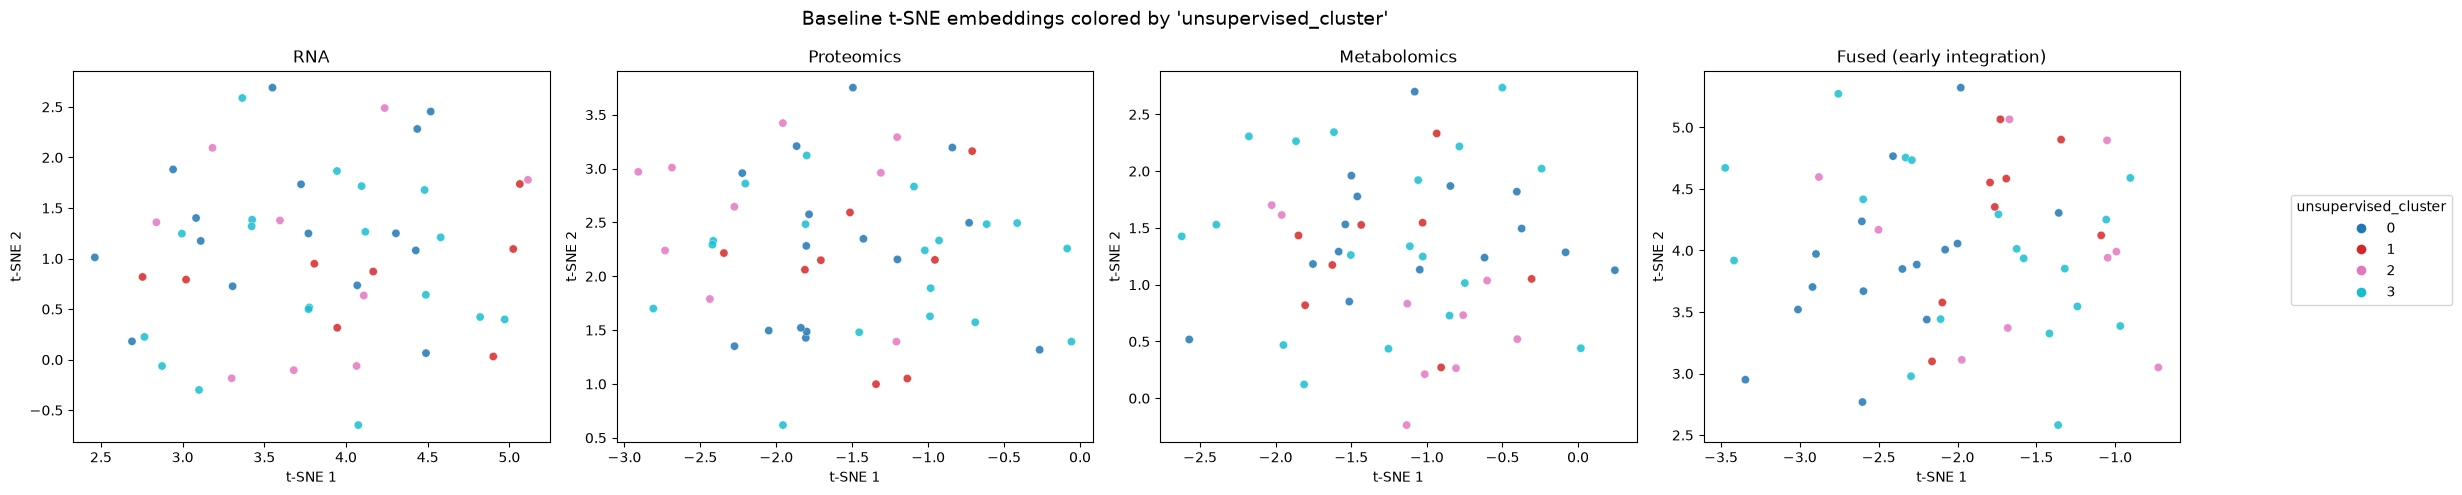

[OK] Saved figure: processed_data/baseline_integration_umap.png


In [20]:
# ============================================================================
# STEP 7: Side-by-side visualization of all embeddings
# ============================================================================
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

is_categorical = not pd.api.types.is_numeric_dtype(color_values) or color_values.nunique() <= 10
if is_categorical:
    categories = pd.Categorical(color_values)
    codes = categories.codes
    cmap = plt.get_cmap("tab10")
else:
    codes = color_values.values
    cmap = plt.get_cmap("viridis")

for ax, (name, emb) in zip(axes, embeddings.items()):
    scatter = ax.scatter(emb[:, 0], emb[:, 1], c=codes, cmap=cmap, s=35, alpha=0.85, edgecolors="white", linewidths=0.3)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel(f"{method_name} 1")
    ax.set_ylabel(f"{method_name} 2")

if is_categorical:
    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=cmap(i / max(1, len(categories.categories) - 1)),
                          markersize=8, label=str(cat)) for i, cat in enumerate(categories.categories)]
    fig.legend(handles=handles, title=color_col, loc="center right", bbox_to_anchor=(1.12, 0.5))
else:
    fig.colorbar(scatter, ax=axes, shrink=0.7, label=color_col)

fig.suptitle(f"Baseline {method_name} embeddings colored by '{color_col}'", fontsize=14)
plt.tight_layout()
plt.savefig("processed_data/baseline_integration_umap.png", dpi=150, bbox_inches="tight")
plt.show()

print("[OK] Saved figure: processed_data/baseline_integration_umap.png")


In [21]:
# ============================================================================
# STEP 8: Summary of all representation dimensions
# ============================================================================
print("="*70)
print("Baseline Multi-Omics Integration: Dimension Summary")
print("="*70)
print(f"\n{'Representation':<28s}{'Samples':>10s}{'Features':>12s}")
print("-"*50)
print(f"{'RNA (processed)':<28s}{rna.shape[0]:>10d}{rna.shape[1]:>12d}")
print(f"{'Proteomics (processed)':<28s}{prot.shape[0]:>10d}{prot.shape[1]:>12d}")
print(f"{'Metabolomics (processed)':<28s}{met.shape[0]:>10d}{met.shape[1]:>12d}")
print("-"*50)
print(f"{'RNA PCA':<28s}{rna_pca.shape[0]:>10d}{rna_pca.shape[1]:>12d}")
print(f"{'Proteomics PCA':<28s}{prot_pca.shape[0]:>10d}{prot_pca.shape[1]:>12d}")
print(f"{'Metabolomics PCA':<28s}{met_pca.shape[0]:>10d}{met_pca.shape[1]:>12d}")
print(f"{'Fused (early integration)':<28s}{fused_pca.shape[0]:>10d}{fused_pca.shape[1]:>12d}")
print("-"*50)
print(f"2D embedding method used: {method_name}")
print("\n[OK] Baseline PCA + early-fusion integration complete")


Baseline Multi-Omics Integration: Dimension Summary

Representation                 Samples    Features
--------------------------------------------------
RNA (processed)                     50         100
Proteomics (processed)              50          80
Metabolomics (processed)            50         150
--------------------------------------------------
RNA PCA                             50          20
Proteomics PCA                      50          20
Metabolomics PCA                    50          20
Fused (early integration)           50          60
--------------------------------------------------
2D embedding method used: t-SNE

[OK] Baseline PCA + early-fusion integration complete


## What this baseline is doing

**PCA per modality.** For each omics layer (RNA, proteomics, metabolomics) we fit a
separate `PCA` that projects the standardized features onto a small number of orthogonal
components (10-20, capped by sample size). Each component is the linear combination of
original features that explains the most remaining variance. This gives a compact
low-dimensional summary of each modality's dominant axes of biological variation.

**Why PCA is useful for high-dimensional omics data.** Omics matrices are typically
"wide" (far more features than samples), which makes downstream distance-based methods
(clustering, UMAP/t-SNE, nearest-neighbor models) noisy, slow, and prone to overfitting.
PCA denoises the data by discarding low-variance directions (often dominated by
measurement noise), reduces dimensionality by 5-10x, and decorrelates features so that
later steps (fusion, embedding) operate on a small set of informative, independent axes.

**What early fusion means.** "Early fusion" here means concatenating the per-modality
PCA score matrices *before* any further modeling: `[RNA_PCA | Proteomics_PCA |
Metabolomics_PCA]` becomes one wide feature vector per sample. It is the simplest
possible multi-omics integration strategy - no modality-specific weighting, no
learned interactions, just horizontal stacking.

**What information may be lost by simple concatenation.**
- **Cross-modality relationships are not modeled.** Concatenation treats each
  modality's PCs as independent, unweighted features - it cannot learn that,
  say, a specific transcript's PC loading co-varies with a specific protein's PC
  loading (i.e., no cross-modal covariance structure is captured).
- **Unequal modality influence.** Modalities with more retained PCs or larger PC
  score magnitudes can dominate distance calculations and downstream models,
  even if they are not biologically more informative.
- **Nonlinear interactions are ignored.** PCA and concatenation are both linear;
  any nonlinear, combinatorial, or conditional relationships between omics
  layers (e.g., a metabolite level that only depends on a gene-protein pair)
  are invisible to this representation.
- **Information discarded within each modality.** PCA keeps only the top
  variance components, so lower-variance but potentially biologically
  meaningful signals (e.g., subtle regulatory changes) may be dropped.

This baseline (PCA + early fusion + 2D embedding) is intentionally simple. It
establishes a reference point that a later, learned multi-omics integration model
(e.g., a joint neural network with cross-modal attention or shared latent space)
should be able to improve upon by capturing exactly the cross-modal and nonlinear
structure that this baseline cannot.
